In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [3]:
# Load dataset
df = pd.read_excel(r"C:\Users\Atharva More\Downloads\online_retail_II.xlsx",
                   sheet_name='Year 2010-2011')

# Clean
df_clean = df.dropna(subset=['Customer ID'])
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['Price'] > 0]
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['Price']
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Daily revenue
daily_revenue = df_clean.groupby(df_clean['InvoiceDate'].dt.date)['TotalAmount'].sum().reset_index()
daily_revenue.columns = ['ds', 'y']
daily_revenue['ds'] = pd.to_datetime(daily_revenue['ds'])
daily_revenue = daily_revenue.set_index('ds')

print("✅ Data loaded!")
print(f"📅 Date range: {daily_revenue.index.min()} to {daily_revenue.index.max()}")
print(f"📊 Total days: {len(daily_revenue)}")

✅ Data loaded!
📅 Date range: 2010-12-01 00:00:00 to 2011-12-09 00:00:00
📊 Total days: 305


In [4]:
# ADF Test - checks if time series is stationary
result = adfuller(daily_revenue['y'].dropna())

print("=" * 50)
print("📊 ADF STATIONARITY TEST")
print("=" * 50)
print(f"ADF Statistic: {result[0]:.4f}")
print(f"P-value: {result[1]:.4f}")
print(f"Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")
print()
if result[1] <= 0.05:
    print("✅ STATIONARY - Good for forecasting!")
else:
    print("⚠️ NON-STATIONARY - Needs differencing")
print("=" * 50)

📊 ADF STATIONARITY TEST
ADF Statistic: -0.3660
P-value: 0.9156
Critical Values:
   1%: -3.4529
   5%: -2.8715
   10%: -2.5721

⚠️ NON-STATIONARY - Needs differencing


In [5]:
# KPSS Test - second stationarity check
result_kpss = kpss(daily_revenue['y'].dropna(), regression='c')

print("=" * 50)
print("📊 KPSS STATIONARITY TEST")
print("=" * 50)
print(f"KPSS Statistic: {result_kpss[0]:.4f}")
print(f"P-value: {result_kpss[1]:.4f}")
print(f"Critical Values:")
for key, value in result_kpss[3].items():
    print(f"   {key}: {value:.4f}")
print()
if result_kpss[1] >= 0.05:
    print("✅ STATIONARY confirmed!")
else:
    print("⚠️ NON-STATIONARY confirmed - will apply differencing")
print("=" * 50)

📊 KPSS STATIONARITY TEST
KPSS Statistic: 1.8995
P-value: 0.0100
Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390

⚠️ NON-STATIONARY confirmed - will apply differencing


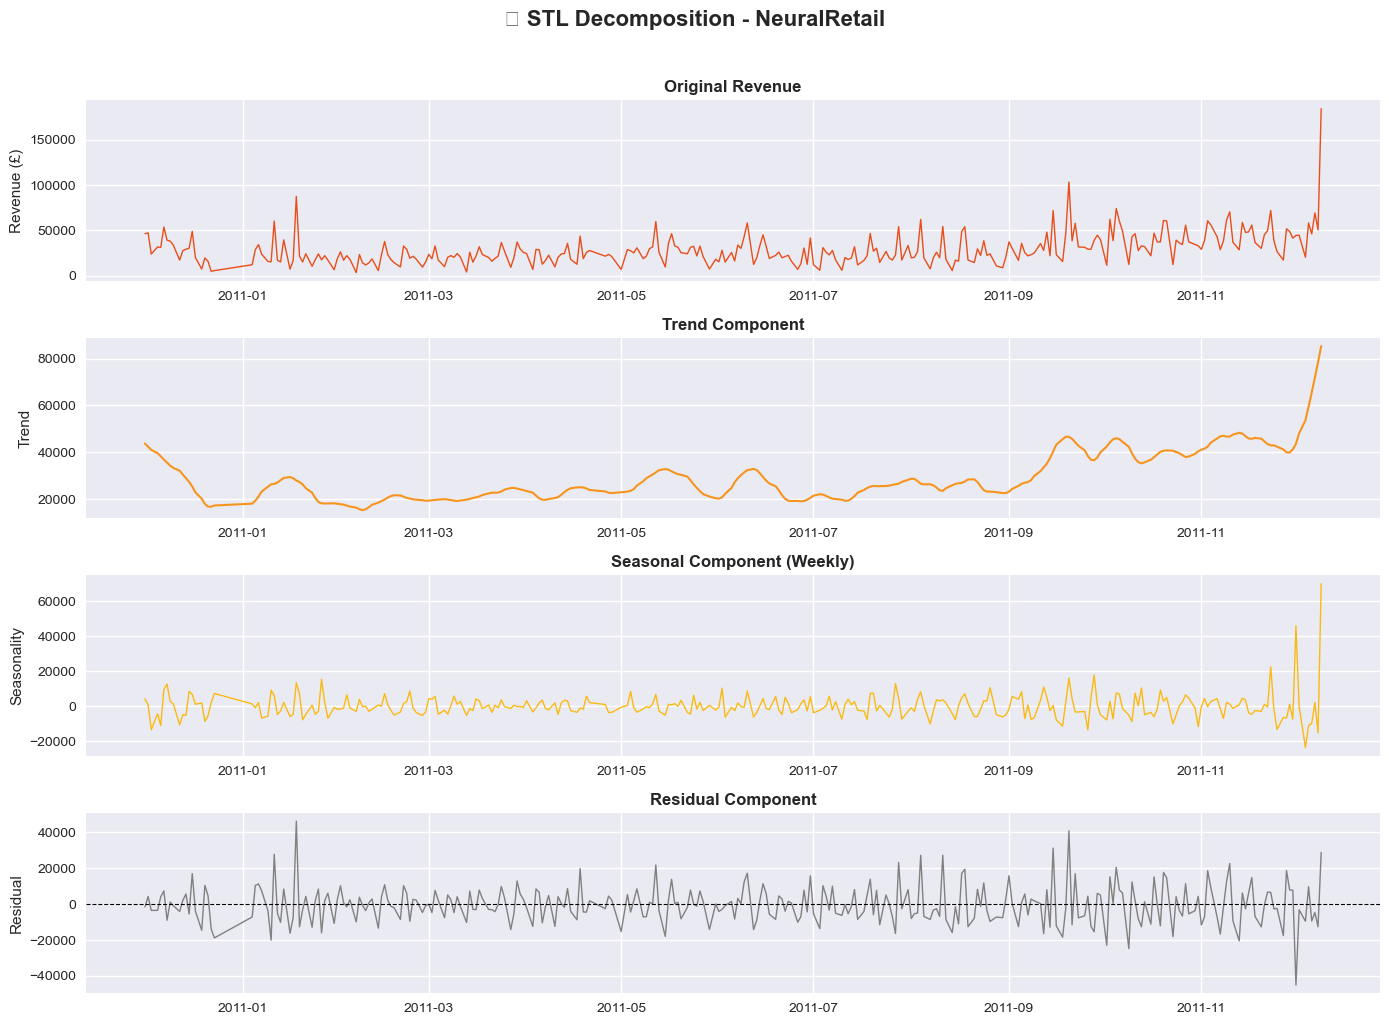

✅ STL Decomposition chart saved!


In [6]:
# STL Decomposition - breaks series into trend, seasonality, residual
stl = STL(daily_revenue['y'], period=7)
result_stl = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

axes[0].plot(daily_revenue.index, daily_revenue['y'], color='#E84E1B', linewidth=1)
axes[0].set_title('Original Revenue', fontweight='bold')
axes[0].set_ylabel('Revenue (£)')

axes[1].plot(daily_revenue.index, result_stl.trend, color='#F7941D', linewidth=1.5)
axes[1].set_title('Trend Component', fontweight='bold')
axes[1].set_ylabel('Trend')

axes[2].plot(daily_revenue.index, result_stl.seasonal, color='#FBBA13', linewidth=1)
axes[2].set_title('Seasonal Component (Weekly)', fontweight='bold')
axes[2].set_ylabel('Seasonality')

axes[3].plot(daily_revenue.index, result_stl.resid, color='gray', linewidth=1)
axes[3].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[3].set_title('Residual Component', fontweight='bold')
axes[3].set_ylabel('Residual')

plt.suptitle('📊 STL Decomposition - NeuralRetail', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r"C:\Users\Atharva More\NeuralRetail\reports\stl_decomposition.png", dpi=150)
plt.show()
print("✅ STL Decomposition chart saved!")

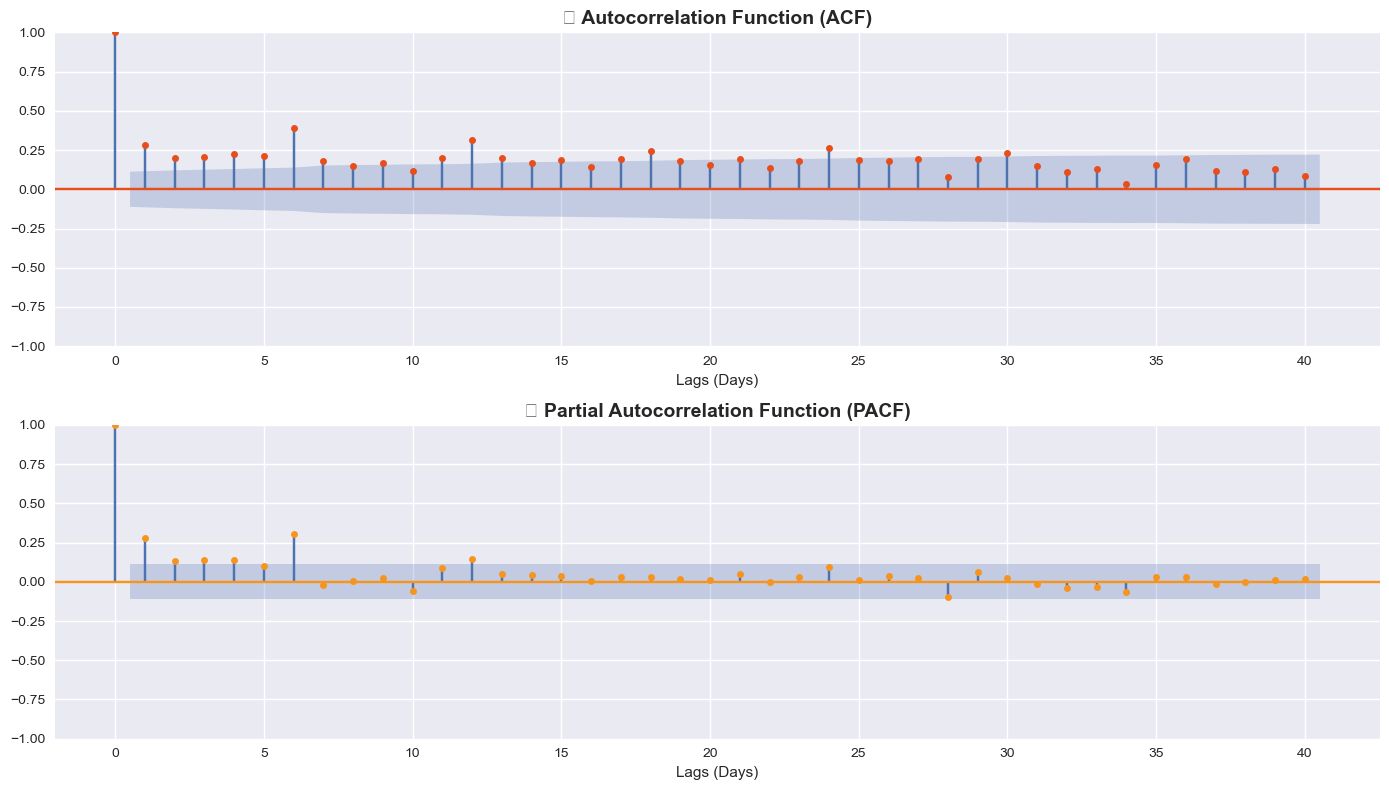

✅ ACF/PACF charts saved!


In [8]:
# ACF and PACF plots
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(daily_revenue['y'].dropna(), lags=40, ax=axes[0], color='#E84E1B')
axes[0].set_title('📊 Autocorrelation Function (ACF)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lags (Days)')

plot_pacf(daily_revenue['y'].dropna(), lags=40, ax=axes[1], color='#F7941D')
axes[1].set_title('📊 Partial Autocorrelation Function (PACF)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lags (Days)')

plt.tight_layout()
plt.savefig(r"C:\Users\Atharva More\NeuralRetail\reports\acf_pacf.png", dpi=150)
plt.show()
print("✅ ACF/PACF charts saved!")

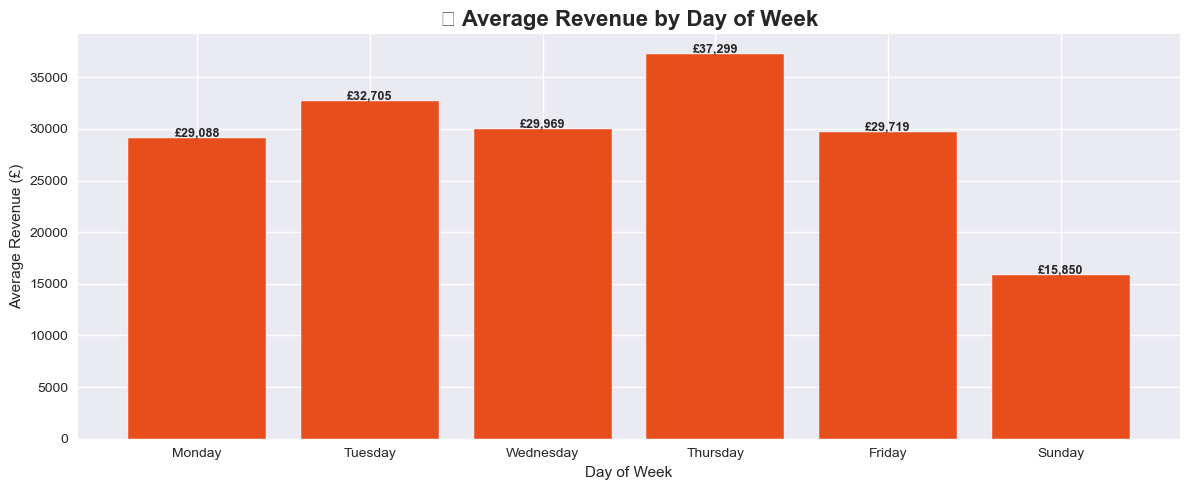

✅ Weekly seasonality chart saved!


In [8]:
# Weekly seasonality analysis
daily_revenue_reset = daily_revenue.reset_index()
daily_revenue_reset['DayOfWeek'] = daily_revenue_reset['ds'].dt.day_name()
daily_revenue_reset['WeekNumber'] = daily_revenue_reset['ds'].dt.isocalendar().week

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
weekly_pattern = daily_revenue_reset.groupby('DayOfWeek')['y'].mean().reindex(day_order)

plt.figure(figsize=(12, 5))
bars = plt.bar(weekly_pattern.index, weekly_pattern.values, color='#E84E1B', edgecolor='white')
plt.title('📅 Average Revenue by Day of Week', fontsize=16, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Average Revenue (£)')
for bar, val in zip(bars, weekly_pattern.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'£{val:,.0f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Users\Atharva More\NeuralRetail\reports\weekly_seasonality.png", dpi=150)
plt.show()
print("✅ Weekly seasonality chart saved!")

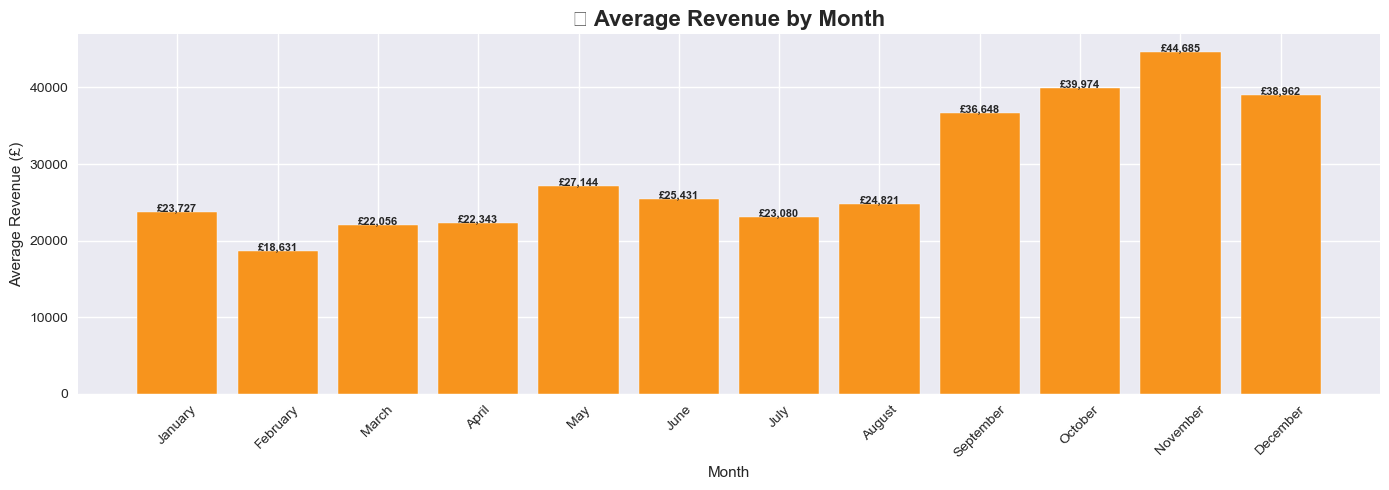

✅ Monthly seasonality chart saved!


In [9]:
# Monthly seasonality
daily_revenue_reset['Month'] = daily_revenue_reset['ds'].dt.month_name()
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly_pattern = daily_revenue_reset.groupby('Month')['y'].mean().reindex(month_order).dropna()

plt.figure(figsize=(14, 5))
bars = plt.bar(monthly_pattern.index, monthly_pattern.values, color='#F7941D', edgecolor='white')
plt.title('📅 Average Revenue by Month', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Revenue (£)')
plt.xticks(rotation=45)
for bar, val in zip(bars, monthly_pattern.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'£{val:,.0f}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Users\Atharva More\NeuralRetail\reports\monthly_seasonality.png", dpi=150)
plt.show()
print("✅ Monthly seasonality chart saved!")

In [10]:
print("=" * 55)
print("📊 TIME SERIES ANALYSIS SUMMARY")
print("=" * 55)
print(f"📅 Total Days Analyzed: {len(daily_revenue)}")
print(f"💰 Mean Daily Revenue: £{daily_revenue['y'].mean():,.2f}")
print(f"📈 Max Daily Revenue: £{daily_revenue['y'].max():,.2f}")
print(f"📉 Min Daily Revenue: £{daily_revenue['y'].min():,.2f}")
print(f"📊 Std Deviation: £{daily_revenue['y'].std():,.2f}")
print(f"\n🏆 Best Sales Day: {weekly_pattern.idxmax()}")
print(f"📉 Worst Sales Day: {weekly_pattern.idxmin()}")
print(f"🏆 Best Sales Month: {monthly_pattern.idxmax()}")
print(f"📉 Worst Sales Month: {monthly_pattern.idxmin()}")
print("=" * 55)
print("✅ Day 6 - Time Series Deep Dive Complete!")
print("=" * 55)

📊 TIME SERIES ANALYSIS SUMMARY
📅 Total Days Analyzed: 305
💰 Mean Daily Revenue: £29,217.79
📈 Max Daily Revenue: £184,367.28
📉 Min Daily Revenue: £3,457.11
📊 Std Deviation: £17,855.51

🏆 Best Sales Day: Thursday
📉 Worst Sales Day: Sunday
🏆 Best Sales Month: November
📉 Worst Sales Month: February
✅ Day 6 - Time Series Deep Dive Complete!
